In [18]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from pathlib import Path
from lightkurve import KeplerLightCurveFile
import math
from gatspy.periodic import *

In [19]:
pwd

'/Users/tmishra/Downloads/roto/roto2.0/roto-project'

In [22]:
path_to_files = "/Users/tmishra/Downloads/roto/roto2.0/roto-project/MAST_2025-10-23T2232/MAST_2025-10-23T2232/Kepler/kplr005110407_lc_Q001111011101110111/kplr005110407_lc_Q001111011101110111_all_files/005110407"

In [23]:
folder = Path(path_to_files)

# find all .fits files in the folder (non-recursive)
fits_files = list(folder.glob("*.fits"))

In [24]:
len(fits_files)

13

In [25]:
light_curves= []
for file in fits_files:
    lcfile = KeplerLightCurveFile(file)
    lc = lcfile.PDCSAP_FLUX.remove_nans()
    light_curves.append(lc)

/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.py:4: LightkurveDeprecationWarning: The PDCSAP_FLUX function is deprecated and may be removed in a future version.
  lc = lcfile.PDCSAP_FLUX.remove_nans()
/var/folders/jk/y277gdtn4v16jhh80rvcq17s08jmmm/T/ipykernel_16425/2159991908.

In [26]:
len(light_curves)

13

In [27]:
from sacf import SACF
from scipy.signal import find_peaks

In [28]:
# Combine all light curves into a single time series
times = np.concatenate([lc.time.value for lc in light_curves])
fluxes = np.concatenate([lc.flux.value for lc in light_curves])
errors = np.concatenate([lc.flux_err.value for lc in light_curves])

# Sort by time
sort_idx = np.argsort(times)
times = times[sort_idx]
fluxes = fluxes[sort_idx]
errors = errors[sort_idx]

# Normalize flux (subtract mean, divide by std)
flux_normalized = (fluxes - np.mean(fluxes)) / np.std(fluxes)
errors_normalized = errors / np.std(fluxes)

# Convert to contiguous float64 arrays (required by SACF)
times = np.ascontiguousarray(times, dtype=np.float64)
flux_normalized = np.ascontiguousarray(flux_normalized, dtype=np.float64)
errors_normalized = np.ascontiguousarray(errors_normalized, dtype=np.float64)

print(f"Total data points: {len(times)}")
print(f"Time span: {times[-1] - times[0]:.2f} days")

Total data points: 50190
Time span: 1421.24 days


In [51]:
# Initialize SACF with the time series data
sacf = SACF(timeseries=times, values=flux_normalized, errors=errors_normalized)

# Compute autocorrelation
# max_lag: maximum period to search for (in days)
# lag_resolution: resolution of the lag grid
max_lag = 4  # days - adjust based on expected rotation period
lag_resolution = 0.001  # days

lags, correlations = sacf.autocorrelation(
    min_lag=0.5,
    max_lag=max_lag,
    lag_resolution=lag_resolution
)

print(f"Lag range: {lags[0]:.2f} to {lags[-1]:.2f} days")
print(f"Number of lag points: {len(lags)}")

Lag range: 0.00 to 4.00 days
Number of lag points: 3502


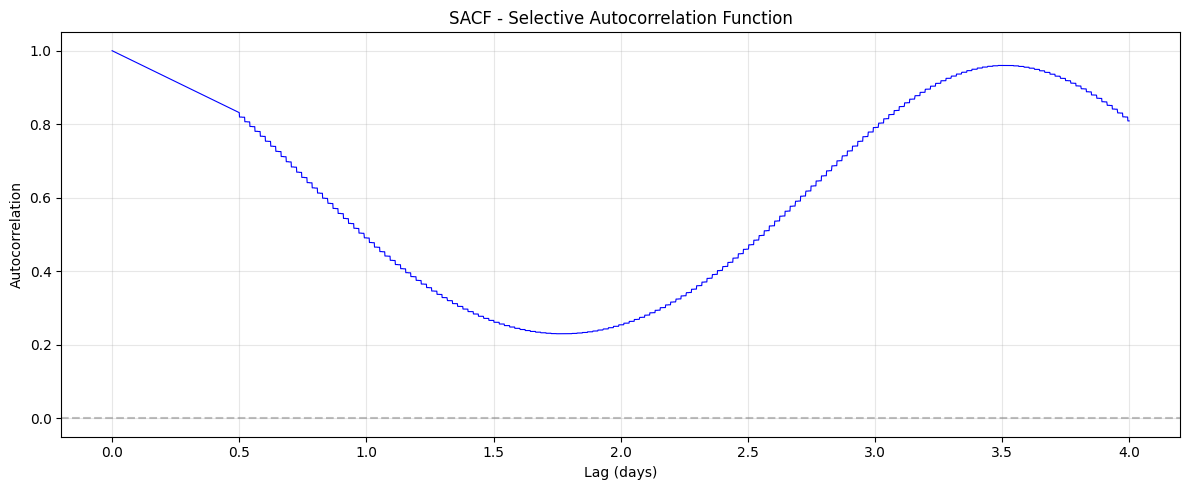

In [52]:
# Plot the autocorrelation function
plt.figure(figsize=(12, 5))
plt.plot(lags, correlations, 'b-', linewidth=0.8)
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.title('SACF - Selective Autocorrelation Function')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# Find the period from the highest peak in the ACF
min_period_search = 1.0  # days - minimum period to consider

# Find peaks in the correlation function
peak_indices, peak_properties = find_peaks(correlations, height=0.1, distance=int(1.0/lag_resolution))

# Filter peaks to those above minimum period
valid_peaks = [(lags[i], correlations[i]) for i in peak_indices if lags[i] >= min_period_search]

if valid_peaks:
    # Sort by correlation strength (descending) and pick the highest
    valid_peaks_sorted = sorted(valid_peaks, key=lambda x: x[1], reverse=True)
    estimated_period = valid_peaks_sorted[0][0]
    peak_correlation = valid_peaks_sorted[0][1]
    
    print(f"Estimated Period: {estimated_period:.3f} days")
    print(f"Peak correlation: {peak_correlation:.3f}")
    print(f"\nAll detected peaks (sorted by correlation):")
    for lag, corr in valid_peaks_sorted[:5]:
        print(f"  {lag:.3f} days (correlation: {corr:.3f})")
else:
    print("No significant peaks found. Try adjusting parameters.")

Estimated Period: 3.514 days
Peak correlation: 0.960

All detected peaks (sorted by correlation):
  3.514 days (correlation: 0.960)
  2.514 days (correlation: 0.472)
  1.512 days (correlation: 0.261)


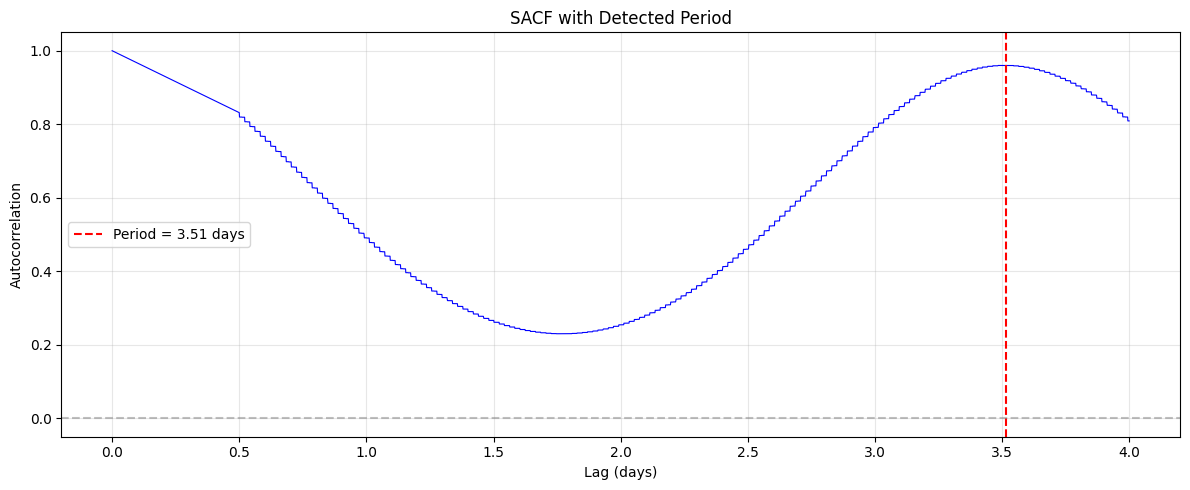

In [54]:
# Plot ACF with detected period marked
plt.figure(figsize=(12, 5))
plt.plot(lags, correlations, 'b-', linewidth=0.8)
if valid_peaks:
    plt.axvline(x=estimated_period, color='r', linestyle='--', label=f'Period = {estimated_period:.2f} days')
    plt.legend()
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.title('SACF with Detected Period')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()